# Feature selection

In [ ]:
from scipy.stats import spearmanr
from tqdm import tqdm
def select_features_spearman(df,feature_cols, target_col, threshold_redundancy=0.85, verbose=True):
    """
    Sélectionne les features par corrélation de Spearman avec la cible,
    puis élimine les redondances entre features sélectionnées.
    
    Args:
        df               : DataFrame avec features et cible
        target_col       : nom de la colonne cible
        threshold_redundancy : seuil de corrélation inter-features (défaut 0.85)
        verbose          : afficher les étapes
    
    Returns:
        selected_features : liste ordonnée des features retenues
        df_results        : DataFrame complet des corrélations
    """
    
    y = df[target_col]
    
    # ── Étape 1 : Corrélation de chaque feature avec la cible ─────────────
    if verbose:
        print("=" * 60)
        print("ÉTAPE 1 — Corrélation Spearman avec la cible")
        print("=" * 60)
    
    results = []

    for col in tqdm(feature_cols):
        # Aligner explicitement sur les index communs APRÈS dropna des deux séries
        idx_common = df[col].dropna().index.intersection(y.dropna().index)
        
        if len(idx_common) < 30:
            if verbose:
                print(f"  ⚠️  {col} : pas assez d'observations ({len(idx_common)}), ignorée")
            continue
        
        # Forcer la conversion en array numpy pour éviter tout problème d'index
        x_arr = df.loc[idx_common, col].to_numpy()
        y_arr = y.loc[idx_common].to_numpy()
        
        rho, pval = spearmanr(x_arr, y_arr)
        results.append({'feature': col, 'rho': rho, 'abs_rho': abs(rho), 'pval': pval})
    
    df_results = (
        pd.DataFrame(results)
        .sort_values('abs_rho', ascending=False)
        .reset_index(drop=True)
    )
    
    if verbose:
        print(f"\n{'Rang':<5} {'Feature':<35} {'Rho':>8} {'|Rho|':>8} {'p-value':>12}")
        print("-" * 70)
        for i, row in df_results.iterrows():
            sig = "***" if row['pval'] < 0.001 else "**" if row['pval'] < 0.01 else "*" if row['pval'] < 0.05 else "ns"
            print(f"  {i+1:<4} {row['feature']:<35} {row['rho']:>+8.3f} {row['abs_rho']:>8.3f} {row['pval']:>10.2e} {sig}")
    
    # ── Étape 2 : Élimination des redondances ─────────────────────────────
    if verbose:
        print(f"\n{'=' * 60}")
        print(f"ÉTAPE 2 — Élimination des redondances (seuil = {threshold_redundancy})")
        print("=" * 60)
        print("  → On parcourt les features dans l'ordre décroissant de |Rho|")
        print("  → On élimine une feature si elle est trop corrélée à une déjà retenue\n")
    
    selected = []
    rejected = []
    
    
    for _, row in df_results.iterrows():
        candidate = row['feature']
        
        if not selected:
            selected.append(candidate)
            if verbose:
                print(f"  ✅ RETENUE  : {candidate:<35} (première feature)")
            continue
        
        # Corrélation avec chaque feature déjà sélectionnée
        max_rho = 0
        max_rho_with = None
        for sel in selected:
            idx_common = df[[candidate, sel]].dropna().index
            rho_inter, _ = spearmanr(df.loc[idx_common, candidate], df.loc[idx_common, sel])
            if abs(rho_inter) > max_rho:
                max_rho = abs(rho_inter)
                max_rho_with = sel
        
        if max_rho >= threshold_redundancy:
            rejected.append(candidate)
            if verbose:
                print(f"  ❌ REJETÉE  : {candidate:<35} |Rho|={max_rho:.3f} avec '{max_rho_with}'")
        else:
            selected.append(candidate)
            if verbose:
                print(f"  ✅ RETENUE  : {candidate:<35} |Rho|_max={max_rho:.3f} (< {threshold_redundancy})")
    
    # ── Étape 3 : Résumé ──────────────────────────────────────────────────
    if verbose:
        print(f"\n{'=' * 60}")
        print("ÉTAPE 3 — Résumé")
        print("=" * 60)
        print(f"  Features candidates  : {len(df_results)}")
        print(f"  Features retenues    : {len(selected)}")
        print(f"  Features rejetées    : {len(rejected)}")
        print(f"\n  Features retenues (ordonnées par |Rho| cible) :")
        df_selected = df_results[df_results['feature'].isin(selected)].reset_index(drop=True)
        for i, row in df_selected.iterrows():
            print(f"    {i+1}. {row['feature']:<35} |Rho|={row['abs_rho']:.3f}")
    
    return selected, df_results



In [ ]:
selected_features, df_correlations = select_features_spearman(
    df=df2,
    feature_cols=features,
    target_col='target_log_time',
    threshold_redundancy=0.7,
    verbose=True
)



ÉTAPE 1 — Corrélation Spearman avec la cible


100%|██████████| 63/63 [04:53<00:00,  4.66s/it]



Rang  Feature                                  Rho    |Rho|      p-value
----------------------------------------------------------------------
  1    min_dist_1min                         +0.594    0.594   0.00e+00 ***
  2    min_dist_5min                         +0.574    0.574   0.00e+00 ***
  3    log_cg_count_5min                     -0.574    0.574   0.00e+00 ***
  4    log_cg_count_10min                    -0.569    0.569   0.00e+00 ***
  5    min_dist_10min                        +0.557    0.557   0.00e+00 ***
  6    log_cg_count_20min                    -0.554    0.554   0.00e+00 ***
  7    mean_dist_5min                        +0.551    0.551   0.00e+00 ***
  8    mean_dist_1min                        +0.548    0.548   0.00e+00 ***
  9    mean_dist_10min                       +0.535    0.535   0.00e+00 ***
  10   cg_20km                               -0.531    0.531   0.00e+00 ***
  11   alert_duration                        -0.516    0.516   0.00e+00 ***
  12   log_count_5m

# light GBM

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import roc_auc_score, brier_score_loss
import optuna

In [ ]:
X_train = train[selected_features]
y_train = train["target_log_time"]

X_val = val[selected_features]
y_val = val["target_log_time"]

X_test = test[selected_features]
y_test = test["target_log_time"]

In [ ]:
# ── 1. Baseline LightGBM sans tuning ──────────────────────────────────────
print("\n" + "="*60)
print("ÉTAPE 1 — Baseline LightGBM (paramètres par défaut)")
print("="*60)

baseline_params = {
    'objective':    'regression',   # changer en 'binary' si cible binaire
    'metric':       'rmse',         # ou 'auc' si binaire
    'n_estimators': 1000,
    'learning_rate': 0.05,
    'num_leaves':   31,
    'random_state': 42,
    'n_jobs':       -1,
    'verbose':      -1,
}

model_baseline = lgb.LGBMRegressor(**baseline_params)  # LGBMClassifier si binaire
model_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=True), lgb.log_evaluation(100)]
)

y_pred_baseline = model_baseline.predict(X_test)
rmse_baseline = np.sqrt(np.mean((y_test - y_pred_baseline)**2))
print(f"\n  RMSE baseline : {rmse_baseline:.4f}")
print(f"  Best iteration : {model_baseline.best_iteration_}")




ÉTAPE 1 — Baseline LightGBM (paramètres par défaut)
Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 1.15366
Early stopping, best iteration is:
[120]	valid_0's rmse: 1.15124

  RMSE baseline : 1.2197
  Best iteration : 120


In [ ]:
# ── 2. Tuning avec Optuna ─────────────────────────────────────────────────
print("\n" + "="*60)
print("ÉTAPE 2 — Tuning Optuna (TimeSeriesSplit × 5)")
print("="*60)

tscv = TimeSeriesSplit(n_splits=5)
tune_train = df2[df2["year"] <= 2021][features]
tune_y_train = df2[df2["year"] <= 2021]["target_log_time"]
def objective(trial):
    params = {
        'objective':        'regression',
        'metric':           'rmse',
        'verbosity':        -1,
        'n_jobs':           -1,
        'random_state':     42,
        # Hyperparamètres à tuner
        'n_estimators':     trial.suggest_int('n_estimators', 200, 2000),
        'learning_rate':    trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 16, 256),
        'max_depth':        trial.suggest_int('max_depth', 3, 12),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 200),
        'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-4, 10.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-4, 10.0, log=True),
    }
    
    scores = []
    for fold, (tr_idx, val_idx) in enumerate(tscv.split(tune_train)):
        X_tr,  X_val  = tune_train.iloc[tr_idx],  tune_train.iloc[val_idx]
        y_tr,  y_val  = tune_y_train.iloc[tr_idx],  tune_y_train.iloc[val_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(30, verbose=False), lgb.log_evaluation(-1)]
        )
        pred  = model.predict(X_val)
        rmse  = np.sqrt(np.mean((y_val - pred)**2))
        scores.append(rmse)
    
    mean_score = np.mean(scores)
    trial.set_user_attr('std', np.std(scores))
    return mean_score

# Lancement de l'optimisation
sampler = optuna.samplers.TPESampler(seed=42)
study   = optuna.create_study(direction='minimize', sampler=sampler)
optuna.logging.set_verbosity(optuna.logging.WARNING)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"\n  Meilleur RMSE CV  : {study.best_value:.4f}")
print(f"  Std               : {study.best_trial.user_attrs['std']:.4f}")
print(f"\n  Meilleurs paramètres :")
for k, v in study.best_params.items():
    print(f"    {k:<25} = {v}")




ÉTAPE 2 — Tuning Optuna (TimeSeriesSplit × 5)


[I 2026-03-14 14:11:14,284] A new study created in memory with name: no-name-a679b91d-d150-4be7-aa78-5779f9642fed
Best trial: 3. Best value: 1.30747:  18%|█▊        | 9/50 [28:16<2:08:47, 188.47s/it]


[W 2026-03-14 14:39:30,417] Trial 9 failed with parameters: {'n_estimators': 1322, 'learning_rate': 0.006601984958164864, 'num_leaves': 31, 'max_depth': 6, 'min_child_samples': 72, 'subsample': 0.864803089169032, 'colsample_bytree': 0.8187787356776066, 'reg_alpha': 2.7293781650374753, 'reg_lambda': 0.022965432344634346} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\UltraBook 3.1\AppData\Local\Programs\Python\Python312\Lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "C:\Users\UltraBook 3.1\AppData\Local\Temp\ipykernel_8804\2276641701.py", line 34, in objective
    model.fit(
  File "c:\Users\UltraBook 3.1\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py", line 1398, in fit
    super().fit(
  File "c:\Users\UltraBook 3.1\AppData\Local\Programs\Python\Python312\Lib\site-packages\lightgbm\sklearn.py", line 1

KeyboardInterrupt: 

In [ ]:
# ── 3. Entraînement final avec les meilleurs paramètres ───────────────────
print("\n" + "="*60)
print("ÉTAPE 3 — Entraînement final")
print("="*60)

best_params = {
    'objective':    'regression',
    'metric':       'rmse',
    'verbosity':    -1,
    'n_jobs':       -1,
    'random_state': 42,
    **study.best_params
}

model_tuned = lgb.LGBMRegressor(**best_params)
model_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(50)]
)

y_pred_tuned = model_tuned.predict(X_test)
rmse_tuned   = np.sqrt(np.mean((y_test - y_pred_tuned)**2))

print(f"\n  RMSE baseline → tuné : {rmse_baseline:.4f} → {rmse_tuned:.4f}  "
      f"({'+'if rmse_tuned>rmse_baseline else '-'}{abs(rmse_tuned-rmse_baseline):.4f})")



ÉTAPE 3 — Entraînement final
[50]	valid_0's rmse: 1.5663
[100]	valid_0's rmse: 1.52823
[150]	valid_0's rmse: 1.52254

  RMSE baseline → tuné : 1.4796 → 1.4633  (-0.0163)



ÉTAPE 4 — Feature Importance


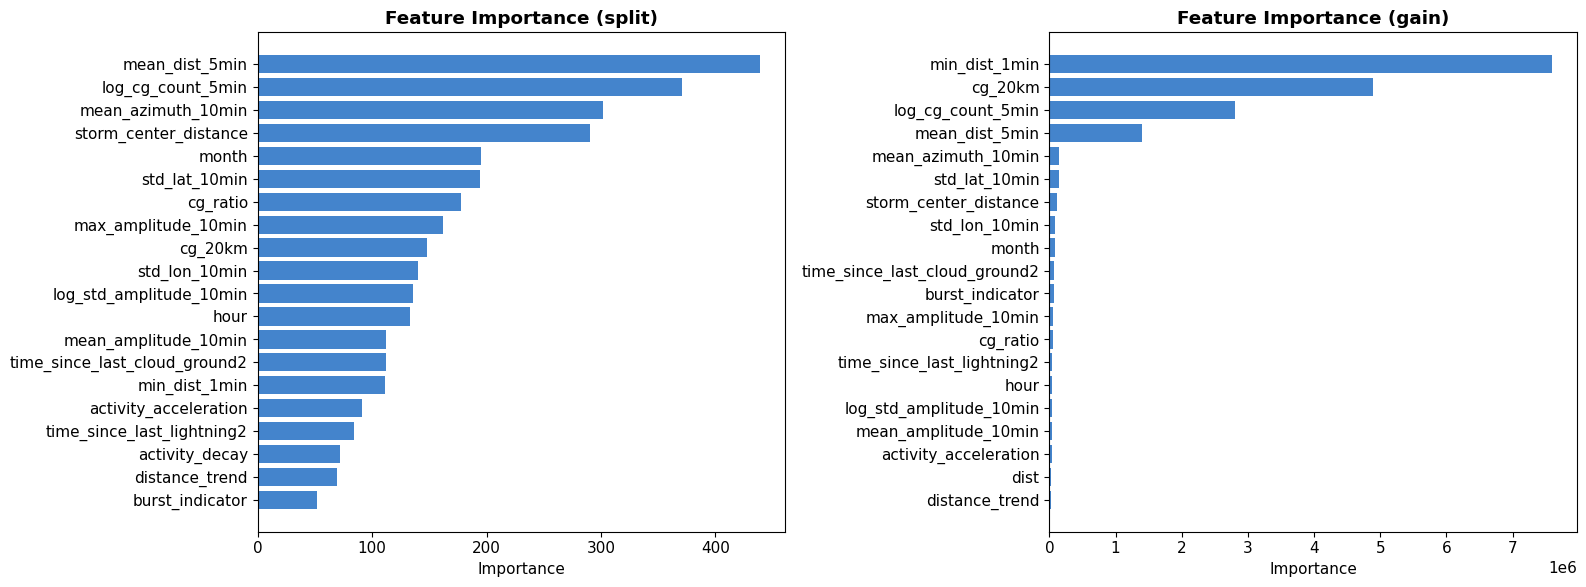

In [ ]:
# ── 4. Feature importance ─────────────────────────────────────────────────
print("\n" + "="*60)
print("ÉTAPE 4 — Feature Importance")
print("="*60)
######################################
model_tuned  = model_baseline
selected_features
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, importance_type in zip(axes, ['split', 'gain']):
    importances = model_tuned.feature_importances_ if importance_type == 'split' \
                  else model_tuned.booster_.feature_importance(importance_type='gain')
    
    df_imp = (
        pd.DataFrame({'feature': selected_features, 'importance': importances})
        .sort_values('importance', ascending=True)
        .tail(20)
    )
    ax.barh(df_imp['feature'], df_imp['importance'], color='#1565C0', alpha=0.8)
    ax.set_title(f'Feature Importance ({importance_type})', fontweight='bold')
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.show()


In [ ]:
# ── 5. Résumé ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("RÉSUMÉ")
print("="*60)
print(f"  Observations train    : {len(X_train):,}")
print(f"  Observations val      : {len(X_val):,}")
print(f"  Observations test     : {len(X_test):,}")
print(f"  Features utilisées    : {len(features)}")
print(f"  Trials Optuna         : {len(study.trials)}")
print(f"  RMSE baseline         : {rmse_baseline:.4f}")
#print(f"  RMSE tuné             : {rmse_tuned:.4f}")
#print(f"  Gain                  : {(rmse_baseline - rmse_tuned) / rmse_baseline * 100:.1f}%")


RÉSUMÉ
  Observations train    : 391,070
  Observations val      : 38,300
  Observations test     : 77,664
  Features utilisées    : 63
  Trials Optuna         : 10
  RMSE baseline         : 1.2197


In [ ]:
pred = np.exp(model_tuned.predict(X_test))-1
obs =  np.exp(y_test) -1
rmse   = np.sqrt(np.mean((obs- pred)**2))
rmse


np.float64(850.2506661628427)

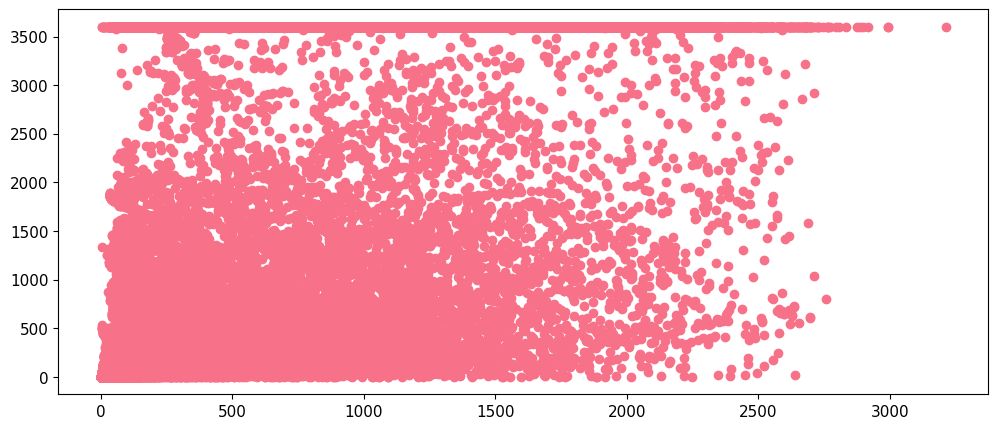

In [ ]:
plt.scatter(pred,obs)

In [ ]:
pred[:20]

array([2.20720063e+04, 1.94974548e+04, 1.78739131e+04, 2.46691688e+01,
       1.14696130e+04, 1.49203256e+04, 5.05548599e+03, 5.81168029e+03,
       5.34718215e+03, 3.75697585e+03, 4.03413206e+03, 2.57423889e+03,
       1.87457431e+03, 1.94072289e+04, 1.24745558e+03, 1.68474004e+03,
       1.13861382e+03, 7.66286893e+02, 1.22280756e+03, 1.61694196e+01])